In [104]:
# Import the libraries
from sklearn.svm import SVR
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import plotly.graph_objects as go
import numpy as np

In [105]:
# Load and view the dataset
dataset = pd.read_csv("C:/Users/buuqu/Downloads/googl_data_2020_2025.csv")
print (dataset)

                           Date   Adj Close       Close        High  \
0     2020-01-02 00:00:00+00:00   68.186821   68.433998   68.433998   
1     2020-01-03 00:00:00+00:00   67.830101   68.075996   68.687500   
2     2020-01-06 00:00:00+00:00   69.638054   69.890503   69.916000   
3     2020-01-07 00:00:00+00:00   69.503548   69.755501   70.175003   
4     2020-01-08 00:00:00+00:00   69.998253   70.251999   70.592499   
...                         ...         ...         ...         ...   
1253  2024-12-24 00:00:00+00:00  196.110001  196.110001  196.110001   
1254  2024-12-26 00:00:00+00:00  195.600006  195.600006  196.750000   
1255  2024-12-27 00:00:00+00:00  192.759995  192.759995  195.320007   
1256  2024-12-30 00:00:00+00:00  191.240005  191.240005  192.550003   
1257  2024-12-31 00:00:00+00:00  189.300003  189.300003  191.960007   

             Low        Open    Volume  
0      67.324501   67.420502  27278000  
1      67.365997   67.400002  23408000  
2      67.550003   67.58

In [106]:
# Check the shape of the dataset
print (dataset.shape)
print (dataset.info())
# Check the data types of the columns
print (dataset.dtypes)  
# Check the summary statistics of the dataset
print (dataset.describe())

(1258, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1258 non-null   object 
 1   Adj Close  1258 non-null   float64
 2   Close      1258 non-null   float64
 3   High       1258 non-null   float64
 4   Low        1258 non-null   float64
 5   Open       1258 non-null   float64
 6   Volume     1258 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 68.9+ KB
None
Date          object
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object
         Adj Close        Close         High          Low         Open  \
count  1258.000000  1258.000000  1258.000000  1258.000000  1258.000000   
mean    118.684965   119.075610   120.378055   117.722657   119.004592   
std      32.403071    32.453265    32.688266    32.248276    32.481362   

In [107]:
# Check for missing values  
print (dataset.isnull().sum())

Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


In [108]:
# Check for duplicates
print (dataset.duplicated().sum())

0


In [109]:
# Prepare data for training
dataset = dataset.head(len(dataset))
dataset

,Date,Adj Close,Close,High,Low,Open,Volume
0,2020-01-02 00:00:00+00:00,68.186821,68.433998,68.433998,67.324501,67.420502,27278000
1,2020-01-03 00:00:00+00:00,67.830101,68.075996,68.687500,67.365997,67.400002,23408000
2,2020-01-06 00:00:00+00:00,69.638054,69.890503,69.916000,67.550003,67.581497,46768000
3,2020-01-07 00:00:00+00:00,69.503548,69.755501,70.175003,69.578003,70.023003,34330000
4,2020-01-08 00:00:00+00:00,69.998253,70.251999,70.592499,69.631500,69.740997,35314000
...,...,...,...,...,...,...,...
1253,2024-12-24 00:00:00+00:00,196.110001,196.110001,196.110001,193.779999,194.839996,10403300
1254,2024-12-26 00:00:00+00:00,195.600006,195.600006,196.750000,194.380005,195.149994,12046600
1255,2024-12-27 00:00:00+00:00,192.759995,192.759995,195.320007,190.649994,194.949997,18891400
1256,2024-12-30 00:00:00+00:00,191.240005,191.240005,192.550003,189.119995,189.800003,14264700


In [110]:
# Remove the time from the date column
dataset['Date'] = pd.to_datetime(dataset['Date']).dt.date
print(dataset)

            Date   Adj Close       Close        High         Low        Open  \
0     2020-01-02   68.186821   68.433998   68.433998   67.324501   67.420502   
1     2020-01-03   67.830101   68.075996   68.687500   67.365997   67.400002   
2     2020-01-06   69.638054   69.890503   69.916000   67.550003   67.581497   
3     2020-01-07   69.503548   69.755501   70.175003   69.578003   70.023003   
4     2020-01-08   69.998253   70.251999   70.592499   69.631500   69.740997   
...          ...         ...         ...         ...         ...         ...   
1253  2024-12-24  196.110001  196.110001  196.110001  193.779999  194.839996   
1254  2024-12-26  195.600006  195.600006  196.750000  194.380005  195.149994   
1255  2024-12-27  192.759995  192.759995  195.320007  190.649994  194.949997   
1256  2024-12-30  191.240005  191.240005  192.550003  189.119995  189.800003   
1257  2024-12-31  189.300003  189.300003  191.960007  188.509995  191.080002   

        Volume  
0     27278000  
1    

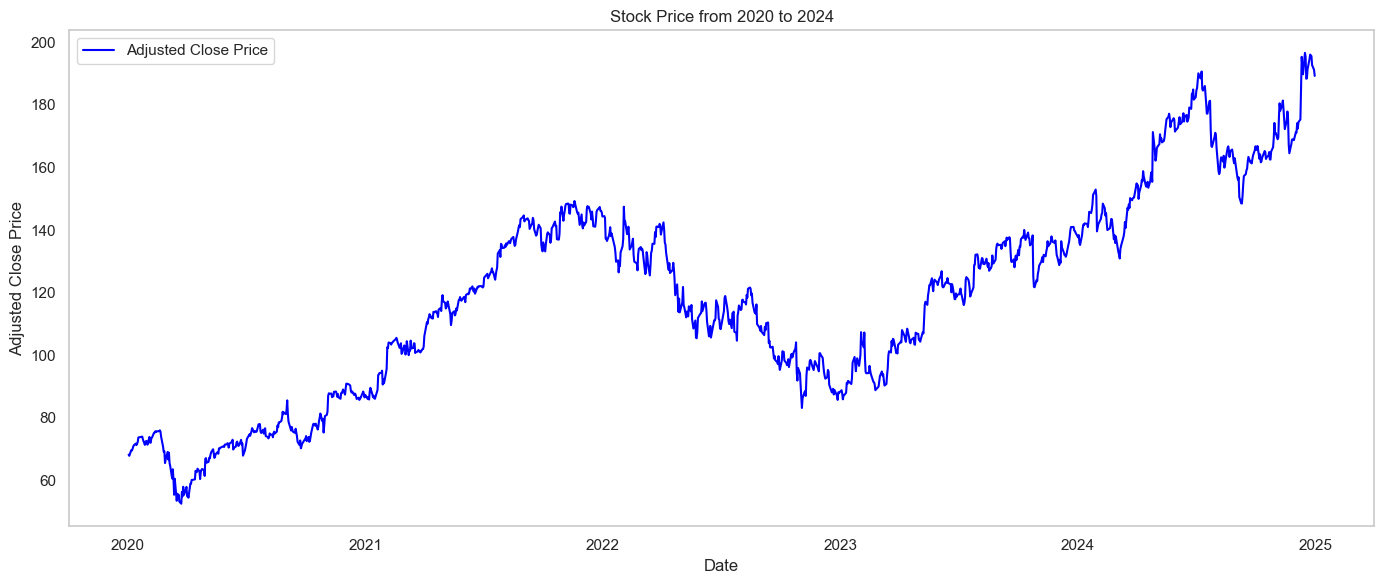

In [111]:
# Filter the dataset for the period from 2020 to 2024
dataset['Date'] = pd.to_datetime(dataset['Date'])  # Ensure 'Date' is in datetime format
filtered_data = dataset[(dataset['Date'] >= '2020-01-01') & (dataset['Date'] <= '2024-12-31')]

# Plot the stock price
plt.figure(figsize=(14, 6))
plt.plot(filtered_data['Date'], filtered_data['Adj Close'], label='Adjusted Close Price', color='blue')
plt.title('Stock Price from 2020 to 2024')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

C:\Users\buuqu\AppData\Local\Temp\ipykernel_26040\3388754736.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year', y='Adj Close', data=dataset, ax=axes[0], palette='Set2')
C:\Users\buuqu\AppData\Local\Temp\ipykernel_26040\3388754736.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='Adj Close', data=dataset, ax=axes[1], palette='Set2')
C:\Users\buuqu\AppData\Local\Temp\ipykernel_26040\3388754736.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DayOfWeek', y='Adj Close', data=dataset, ax=axes[2], palette='Set2'

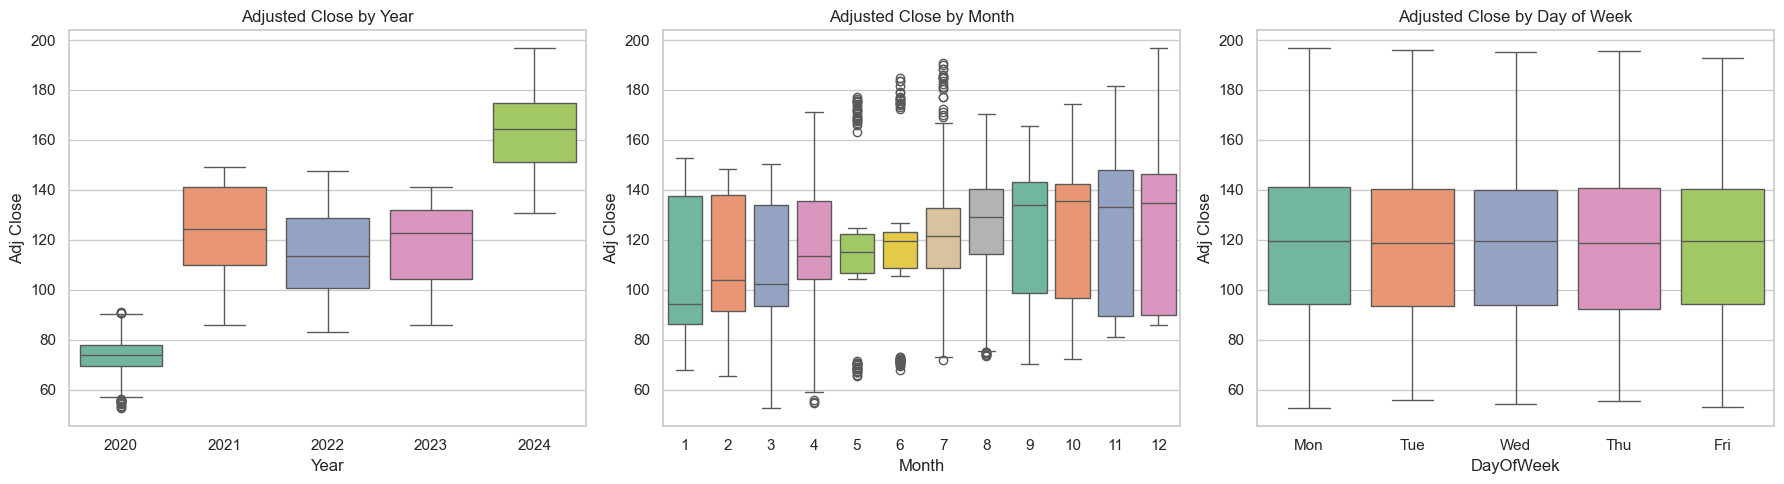

In [112]:
# Extract date-related features
dataset['Date'] = pd.to_datetime(dataset['Date'])
dataset['Year'] = dataset['Date'].dt.year
dataset['Month'] = dataset['Date'].dt.month
dataset['DayOfMonth'] = dataset['Date'].dt.day
dataset['DayOfWeek'] = dataset['Date'].dt.dayofweek # Monday=0, Sunday=6


# Set plot style
sns.set(style="whitegrid")

# Create plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Yearly trend
sns.boxplot(x='Year', y='Adj Close', data=dataset, ax=axes[0], palette='Set2')
axes[0].set_title('Adjusted Close by Year')
axes[0].set_xlabel('Year')

# Monthly seasonality
sns.boxplot(x='Month', y='Adj Close', data=dataset, ax=axes[1], palette='Set2')
axes[1].set_title('Adjusted Close by Month')

# Weekday effect
sns.boxplot(x='DayOfWeek', y='Adj Close', data=dataset, ax=axes[2], palette='Set2')
axes[2].set_title('Adjusted Close by Day of Week')
axes[2].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri'])

plt.tight_layout()
plt.show()

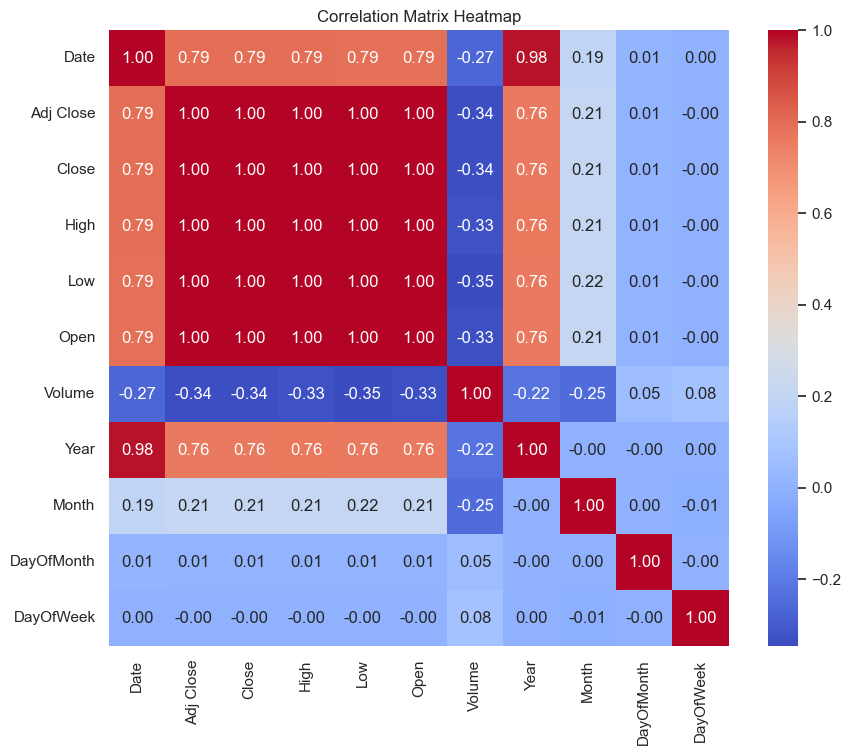

In [113]:
# Calculate the correlation matrix
correlation_matrix = dataset.corr()


# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [114]:
print(dataset)

           Date   Adj Close       Close        High         Low        Open  \
0    2020-01-02   68.186821   68.433998   68.433998   67.324501   67.420502   
1    2020-01-03   67.830101   68.075996   68.687500   67.365997   67.400002   
2    2020-01-06   69.638054   69.890503   69.916000   67.550003   67.581497   
3    2020-01-07   69.503548   69.755501   70.175003   69.578003   70.023003   
4    2020-01-08   69.998253   70.251999   70.592499   69.631500   69.740997   
...         ...         ...         ...         ...         ...         ...   
1253 2024-12-24  196.110001  196.110001  196.110001  193.779999  194.839996   
1254 2024-12-26  195.600006  195.600006  196.750000  194.380005  195.149994   
1255 2024-12-27  192.759995  192.759995  195.320007  190.649994  194.949997   
1256 2024-12-30  191.240005  191.240005  192.550003  189.119995  189.800003   
1257 2024-12-31  189.300003  189.300003  191.960007  188.509995  191.080002   

        Volume  Year  Month  DayOfMonth  DayOfWeek 

In [115]:
# Calculate the average adjusted close price by year
avg_by_year = dataset.groupby('Year')['Adj Close'].mean()
print("Average Adjusted Close Price by Year:")
print(avg_by_year)

# Calculate the average adjusted close price by month
avg_by_month = dataset.groupby('Month')['Adj Close'].mean()
print("Average Adjusted Close Price by Month:")
print(avg_by_month)

# Calculate the average adjusted close price by day of the week
avg_by_day_of_week = dataset.groupby('DayOfWeek')['Adj Close'].mean()
print("\nAverage Adjusted Close Price by Day of the Week:")
print(avg_by_day_of_week)


Average Adjusted Close Price by Year:
Year
2020     73.682551
2021    123.776188
2022    114.345857
2023    118.365635
2024    163.413419
Name: Adj Close, dtype: float64
Average Adjusted Close Price by Month:
Month
1     106.730840
2     110.340014
3     106.526499
4     113.242937
5     117.722076
6     119.117467
7     123.915628
8     125.183992
9     121.680845
10    123.226983
11    126.517439
12    128.998914
Name: Adj Close, dtype: float64

Average Adjusted Close Price by Day of the Week:
DayOfWeek
0    119.154339
1    118.870501
2    118.218973
3    118.113101
4    119.115311
Name: Adj Close, dtype: float64


In [116]:
# Extract date-related features
dataset['Year'] = dataset['Date'].dt.year
dataset['Month'] = dataset['Date'].dt.month
dataset['DayOfMonth'] = dataset['Date'].dt.day

# Add lagged features
dataset['Adj_Close_Lag1'] = dataset['Adj Close'].shift(1)
dataset['Adj_Close_Lag2'] = dataset['Adj Close'].shift(2)
dataset['Volume_Lag1'] = dataset['Volume'].shift(1)

# Drop rows with NaN values caused by lagged features
dataset = dataset.dropna()

# Split the dataset into training (2020-2023) and testing (2024)
train_data = dataset[dataset['Date'] <= pd.Timestamp('2023-12-31')]
test_data = dataset[dataset['Date'] >= pd.Timestamp('2024-01-01')]

# Feature selection
X_train = train_data[['High', 'Low', 'Open', 'Volume', 'Year', 'Month', 'DayOfMonth', 'Adj_Close_Lag1', 'Adj_Close_Lag2', 'Volume_Lag1']]
y_train = train_data['Adj Close']
X_test = test_data[['High', 'Low', 'Open', 'Volume', 'Year', 'Month', 'DayOfMonth', 'Adj_Close_Lag1', 'Adj_Close_Lag2', 'Volume_Lag1']]
y_test = test_data['Adj Close']



In [117]:
# Scale the features
from sklearn.preprocessing import scale


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [118]:
# Train the SVR model rbf kernel
regressor_rbf = SVR(kernel='rbf', C=100000, gamma='scale', epsilon=0.01)
regressor_rbf.fit(X_train_scaled, y_train)

# train the SVR model linear kernel
regressor_linear = SVR(kernel='linear', C=1, epsilon=0.01, gamma='scale')
regressor_linear.fit(X_train_scaled, y_train)

# train the SVR model poly kernel
regressor_poly = SVR(kernel='poly', C=1000, gamma='scale', epsilon=0.01)    
regressor_poly.fit(X_train_scaled, y_train)

# Predict on the test set (2024)
y_pred_rbf = regressor_rbf.predict(X_test_scaled)
y_pred_linear = regressor_linear.predict(X_test_scaled)
y_pred_poly = regressor_poly.predict(X_test_scaled)

In [119]:
from sklearn.metrics import r2_score  # Import r2_score
from sklearn.metrics import mean_squared_error  # Import mean_squared_error
# Evaluate the model rbf
mse = mean_squared_error(y_test, y_pred_rbf)
r2 = r2_score(y_test, y_pred_rbf)
print(f"Test (2024) - rbf: MSE = {mse:.4f}, R² = {r2:.4f}")

# Evaluate the model linear
mse = mean_squared_error(y_test, y_pred_linear) 
r2 = r2_score(y_test, y_pred_linear)
print(f"Test (2024) - linear: MSE = {mse:.4f}, R² = {r2:.4f}")

# Evaluate the model poly
mse = mean_squared_error(y_test, y_pred_poly)
r2 = r2_score(y_test, y_pred_poly)
print(f"Test (2024) - poly: MSE = {mse:.4f}, R² = {r2:.4f}")

Test (2024) - rbf: MSE = 3228.8937, R² = -12.5592
Test (2024) - linear: MSE = 1.3488, R² = 0.9943
Test (2024) - poly: MSE = 14151.4230, R² = -58.4267


In [120]:
# Retrieve the corresponding dates for the test data
test_indices = y_test.index  # Get the indices of the test data
test_dates = dataset.loc[test_indices, 'Date']  # Retrieve the dates using the indices

# Create a DataFrame to display the results
results_df = pd.DataFrame({
    'Date': test_data['Date'],
    'Actual': y_test.values,
    'RBF Prediction': y_pred_rbf,
    'Polynomial Prediction': y_pred_poly,
    'Linear Prediction': y_pred_linear
})

# Display the results
print(results_df)

           Date      Actual  RBF Prediction  Polynomial Prediction  \
1006 2024-01-02  137.670929      144.782950             201.900584   
1007 2024-01-03  138.418228      143.040439             201.631916   
1008 2024-01-04  135.897354      141.580222             199.341368   
1009 2024-01-05  135.239746      140.451403             195.495309   
1010 2024-01-08  138.338516      153.008371             197.597679   
...         ...         ...             ...                    ...   
1253 2024-12-24  196.110001      117.512805             398.996368   
1254 2024-12-26  195.600006      126.045262             398.625400   
1255 2024-12-27  192.759995      124.358756             388.013328   
1256 2024-12-30  191.240005      123.670673             383.554674   
1257 2024-12-31  189.300003      128.197735             376.703513   

      Linear Prediction  
1006         137.415443  
1007         138.034728  
1008         137.217635  
1009         135.812284  
1010         137.419344  
...

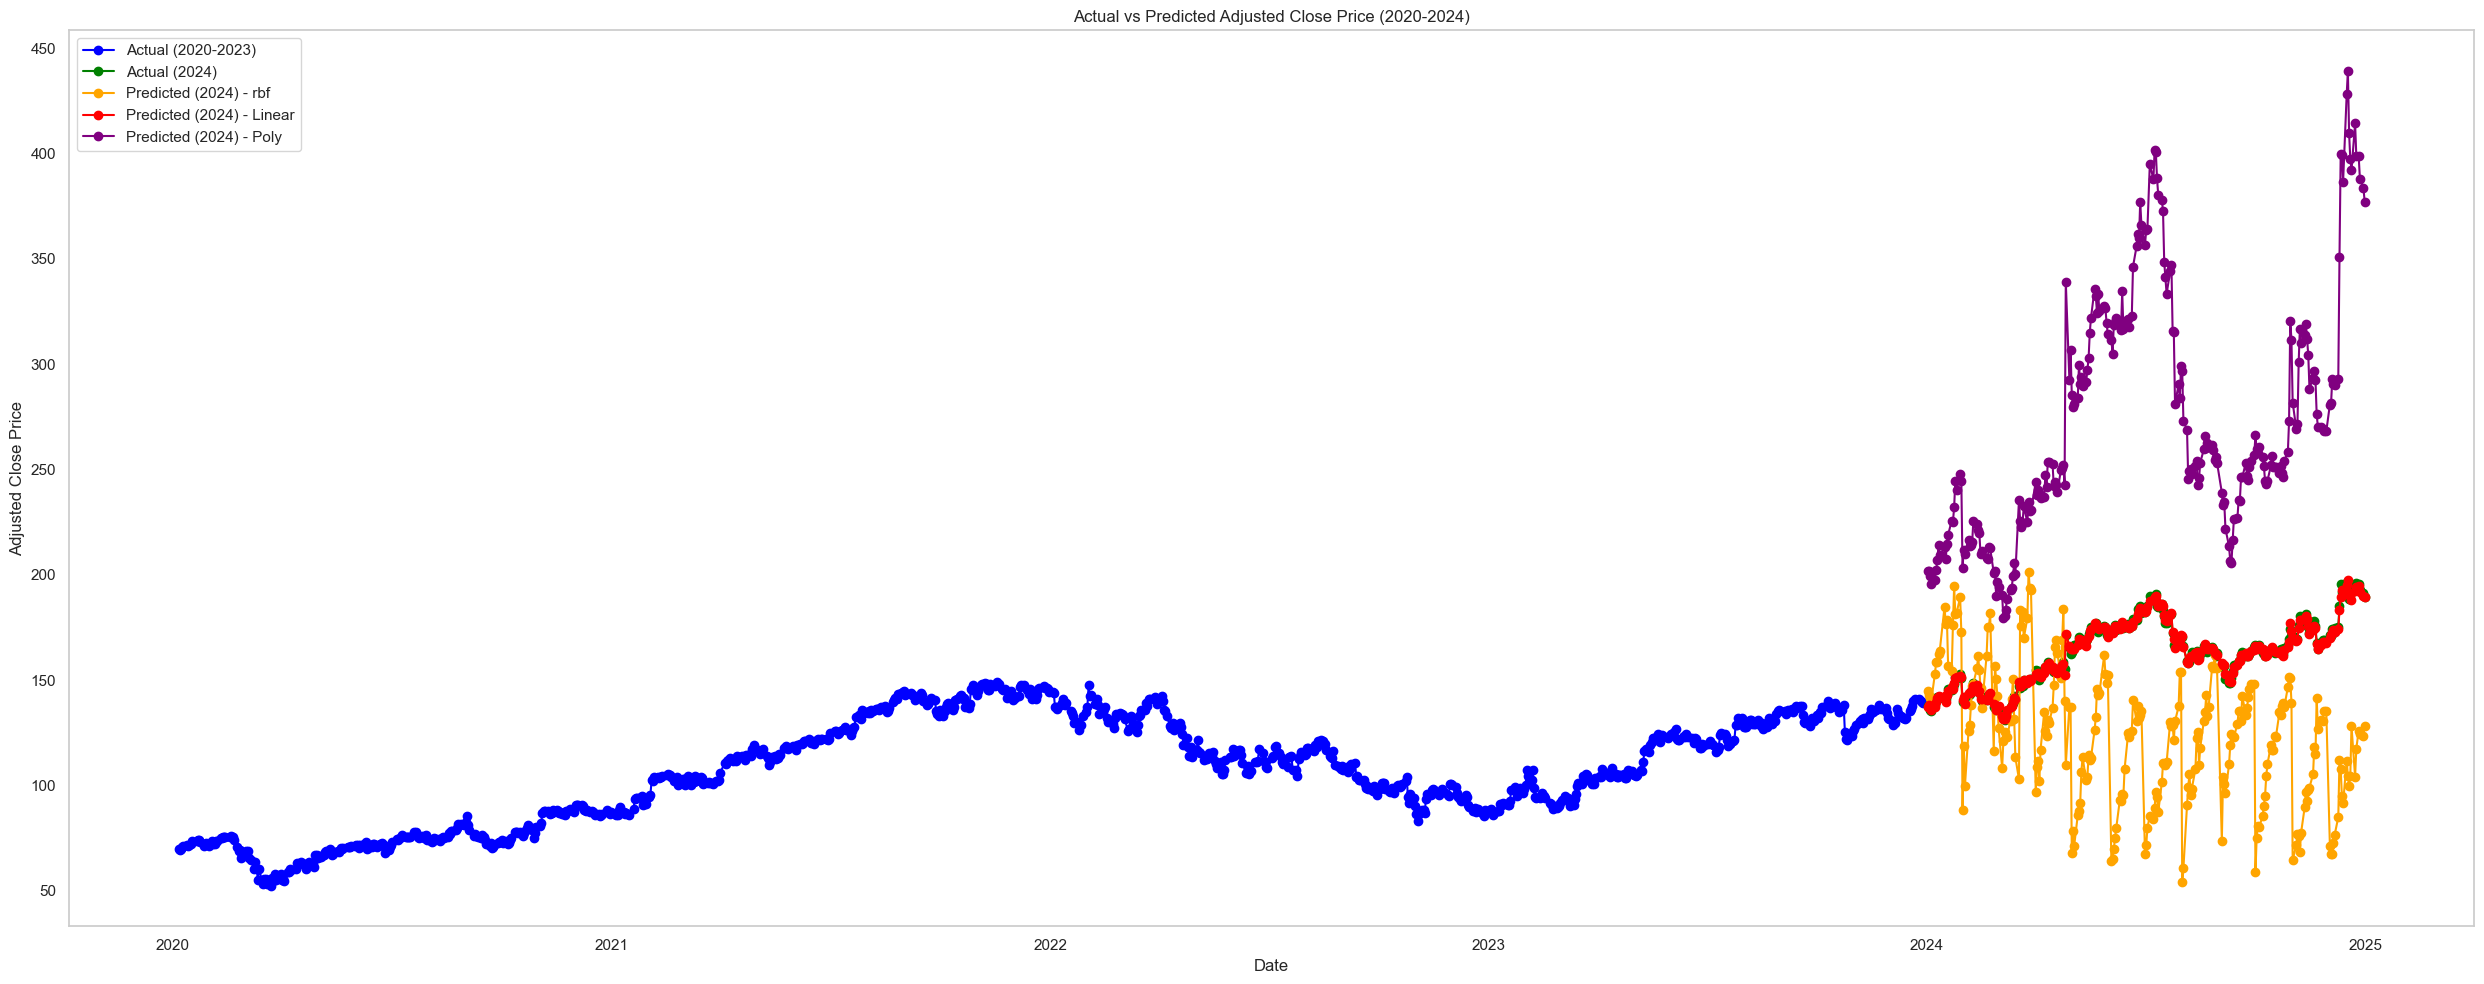

In [121]:
# Plot actual data (2020-2023) and predicted data (2024)
plt.figure(figsize=(25, 10))

# Plot actual data from 2020 to 2023
plt.plot(train_data['Date'], y_train, label='Actual (2020-2023)', color='blue', linestyle='-', marker='o')

# Plot actual data for 2024
plt.plot(test_data['Date'], y_test, label='Actual (2024)', color='green', linestyle='-', marker='o')

# Plot predicted data for 2024
plt.plot(test_data['Date'], y_pred_rbf, label='Predicted (2024) - rbf', color='orange', linestyle='-', marker='o')
plt.plot(test_data['Date'], y_pred_linear, label='Predicted (2024) - Linear', color='red', linestyle='-', marker='o')
plt.plot(test_data['Date'], y_pred_poly, label='Predicted (2024) - Poly', color='purple', linestyle='-', marker='o')

# Add title and labels
plt.title('Actual vs Predicted Adjusted Close Price (2020-2024)')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')

# Add legend
plt.legend()

# Add grid for better readability
plt.grid()

# Show the plot
plt.tight_layout()
plt.show()

Note: you may need to restart the kernel to use updated packages.
 The best solution found:                                                                           
 [8.60249473e+02 3.00792897e-03 2.85404374e-02]

 Objective function:
 18.02209871909874


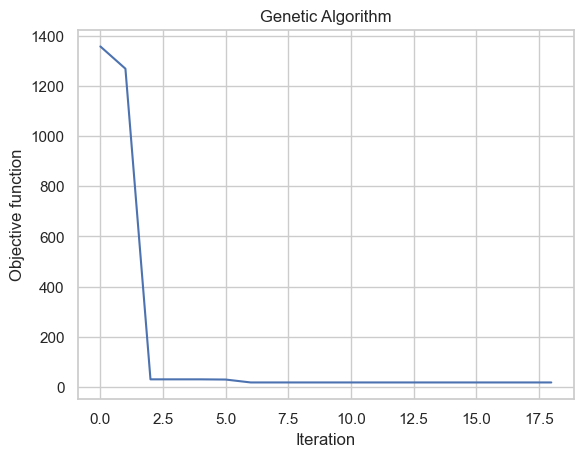

In [122]:
# Install the genetic algorithm library
%pip install geneticalgorithm

from geneticalgorithm import geneticalgorithm as ga


# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the objective function for GA
def svr_objective_function(params):
    C, gamma, epsilon = params
    svr = SVR(kernel='rbf', C=C, gamma=gamma, epsilon=epsilon)
    svr.fit(X_train_scaled, y_train)
    y_pred = svr.predict(X_test_scaled)
    return mean_squared_error(y_test, y_pred)

# Define variable bounds for GA
varbound = np.array([[0.1, 1000],     # C
                     [0.0001, 1],     # gamma
                     [0.001, 1]])     # epsilon

# Define GA model parameters
algorithm_param = {
    'max_num_iteration': 50,
    'population_size': 20,
    'mutation_probability': 0.1,
    'elit_ratio': 0.01,
    'crossover_probability': 0.5,
    'parents_portion': 0.3,
    'crossover_type': 'uniform',
    'max_iteration_without_improv': 10
}

model = ga(function=svr_objective_function,
           dimension=3,
           variable_type='real',
           variable_boundaries=varbound,
           algorithm_parameters=algorithm_param)

# Run the genetic algorithm
model.run()


In [123]:
# Extract the best solution
best_params = model.output_dict['variable']
C_opt, gamma_opt, epsilon_opt = best_params
print("Best Parameters (C, gamma, epsilon):", best_params)

# Train the final SVR model with optimized hyperparameters RBF

svr_optimized = SVR(kernel='rbf', C=C_opt, gamma=gamma_opt, epsilon=epsilon_opt)
svr_optimized.fit(X_train_scaled, y_train)

# Train the final SVR model with optimized hyperparameters Linear
svr_optimized_linear = SVR(kernel='linear', C=C_opt, epsilon=epsilon_opt, gamma=gamma_opt)
svr_optimized_linear.fit(X_train_scaled, y_train)

# Train the final SVR model with optimized hyperparameters Poly
svr_optimized_poly = SVR(kernel='poly', C=C_opt, epsilon=epsilon_opt, gamma=gamma_opt)
svr_optimized_poly.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_optimized_rbf = svr_optimized.predict(X_test_scaled)
y_pred_optimized_linear = svr_optimized_linear.predict(X_test_scaled)
y_pred_optimized_poly = svr_optimized_poly.predict(X_test_scaled)

Best Parameters (C, gamma, epsilon): [8.60249473e+02 3.00792897e-03 2.85404374e-02]


In [124]:
# Evaluate the optimized model RBF
mse_optimized_RBF = mean_squared_error(y_test, y_pred_optimized_rbf)
print("Test MSE with Optimized Parameters in RBF:", mse_optimized_RBF)
r2_optimized_RBF = r2_score(y_test, y_pred_optimized_rbf)
print("Test R² with Optimized Parameters in RBF:", r2_optimized_RBF)


# Evaluate the optimized model Linear
mse_optimized_linear = mean_squared_error(y_test, y_pred_optimized_linear)
print("Test MSE with Optimized Parameters in Linear:", mse_optimized_linear)
r2_optimized_linear = r2_score(y_test, y_pred_optimized_linear)
print("Test R² with Optimized Parameters in Linear:", r2_optimized_linear)

Test MSE with Optimized Parameters in RBF: 18.02209871909874
Test R² with Optimized Parameters in RBF: 0.92431896716399
Test MSE with Optimized Parameters in Linear: 0.9990422473257736
Test R² with Optimized Parameters in Linear: 0.9958046756760744


In [125]:
# Extract the best solution
best_params = model.output_dict['variable']
C_opt, gamma_opt, epsilon_opt = best_params
print("Best Parameters (C, gamma, epsilon):", best_params)

# Train the final SVR model with optimized hyperparameters Poly
svr_optimized_poly = SVR(kernel='poly', C=C_opt, epsilon=epsilon_opt, gamma=gamma_opt)
svr_optimized_poly.fit(X_train_scaled, y_train)

y_pred_optimized_poly = svr_optimized_poly.predict(X_test_scaled)

# Evaluate the optimized model Poly
mse_optimized_poly = mean_squared_error(y_test, y_pred_optimized_poly)
print("Test MSE with Optimized Parameters in Polynomial:", mse_optimized_poly)
r2_optimized_poly = r2_score(y_test, y_pred_optimized_poly)
print("Test R² with Optimized Parameters in Polynomial:", r2_optimized_poly)


Best Parameters (C, gamma, epsilon): [8.60249473e+02 3.00792897e-03 2.85404374e-02]
Test MSE with Optimized Parameters in Polynomial: 1148.5213979280425
Test R² with Optimized Parameters in Polynomial: -3.8230390358109796


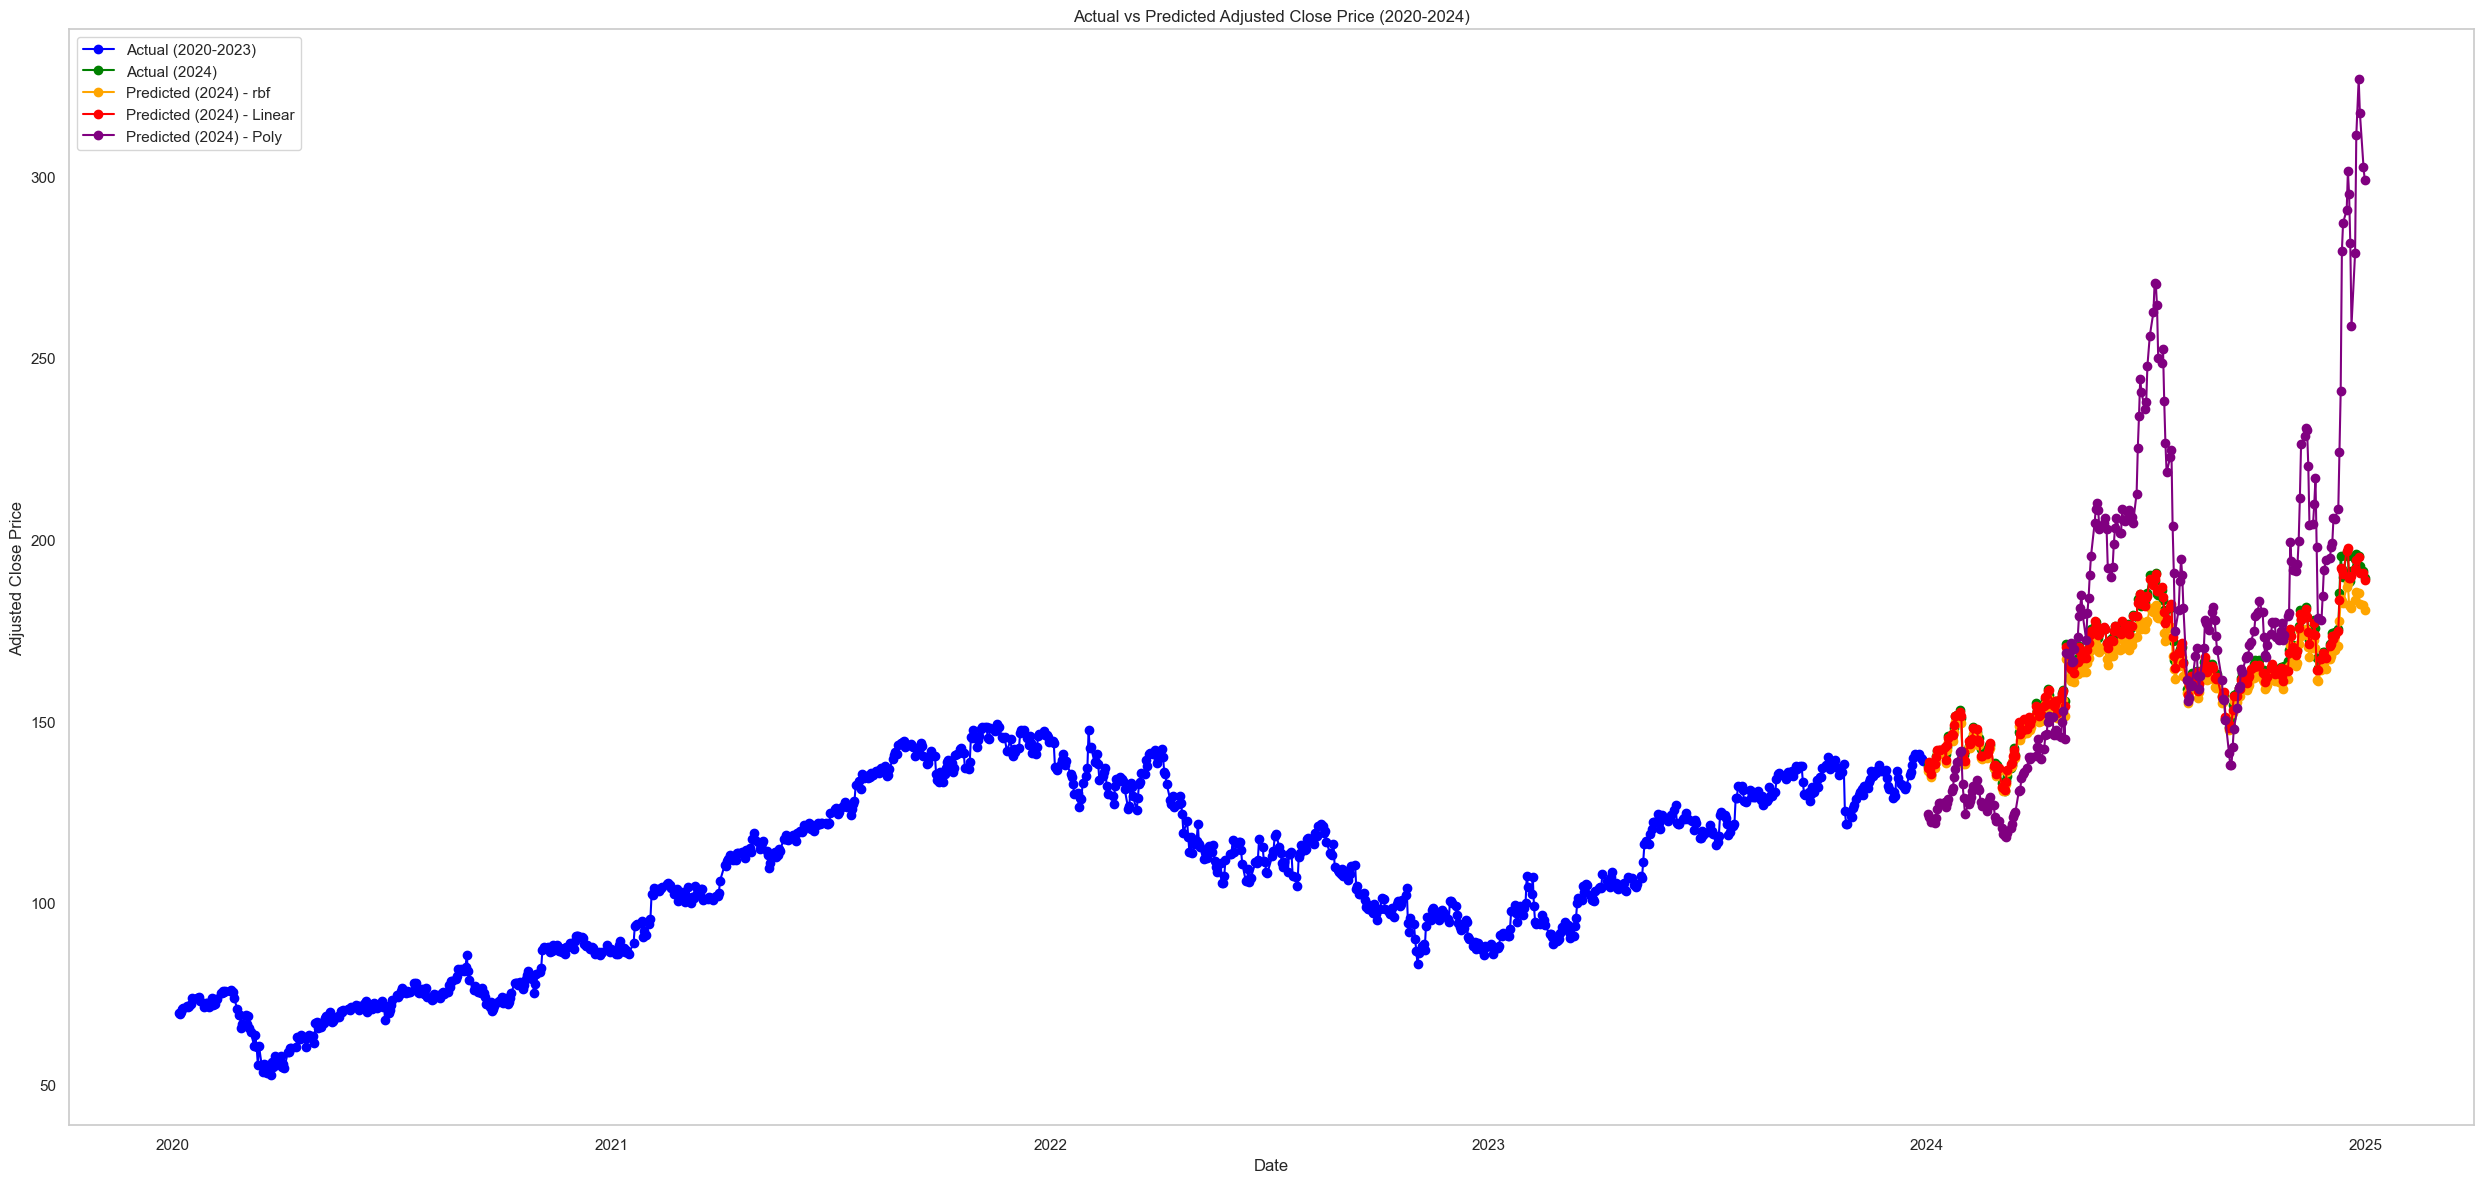

In [126]:
# Plot actual data (2020-2023) and predicted data (2024)
plt.figure(figsize=(25, 12))

# Plot actual data from 2020 to 2023
plt.plot(train_data['Date'], y_train, label='Actual (2020-2023)', color='blue', linestyle='-', marker='o')

# Plot actual data for 2024
plt.plot(test_data['Date'], y_test, label='Actual (2024)', color='green', linestyle='-', marker='o')

# Plot predicted data for 2024
plt.plot(test_data['Date'], y_pred_optimized_rbf, label='Predicted (2024) - rbf', color='orange', linestyle='-', marker='o')
plt.plot(test_data['Date'], y_pred_optimized_linear, label='Predicted (2024) - Linear', color='red', linestyle='-', marker='o')
plt.plot(test_data['Date'], y_pred_optimized_poly, label='Predicted (2024) - Poly', color='purple', linestyle='-', marker='o')

# Add title and labels
plt.title('Actual vs Predicted Adjusted Close Price (2020-2024)')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')

# Add legend
plt.legend()

# Add grid for better readability
plt.grid()

# Show the plot
plt.tight_layout()
plt.show()